# 基于经典PCA的FCCU监控


## 换热器结垢场景

In [1]:
# 导入包 
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 获取NOC训练数据
data_train = pd.read_csv('NOC_varyingFeedFlow_outputs.csv', header=None).values
data_train = data_train[:,1:] # first column gives sampling time

N = data_train.shape[0]
m = data_train.shape[1]

In [3]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#     拟合PCA模型并为训练集生成监控图
############################################################################### 

In [4]:
# 对NOC数据去均值并缩放
scaler = StandardScaler()
scaler.fit(data_train)
scaler.scale_[[3,4,16]] = 1 # these columns have negligible variance and therefore are not scaled to avoid division by zero or very small numbers

data_train_normal = scaler.transform(data_train)

In [5]:
# 拟合PCA模型
pca = PCA()
score_train = pca.fit_transform(data_train_normal)

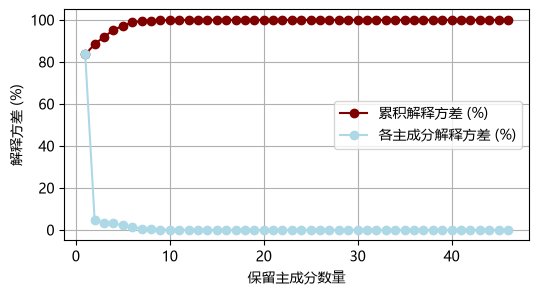

In [6]:
# 绘制碎石图
explained_variance = 100*pca.explained_variance_ratio_ # in percentage
cum_explained_variance = np.cumsum(explained_variance) # cumulative % variance explained

plt.figure(figsize=(6,3))
plt.plot(range(1, len(explained_variance) + 1), cum_explained_variance, color='maroon', marker='o', label = '累积解释方差 (%)')
plt.plot(range(1, len(explained_variance) + 1), explained_variance, color='lightblue', marker='o', label = '各主成分解释方差 (%)')
plt.ylabel('解释方差 (%)')
plt.xlabel('保留主成分数量')
plt.legend()
plt.grid()
plt.show()

In [7]:
# 确定保留的主成分数量并计算主成分空间降维数据
n_comp = np.argmax(cum_explained_variance >= 90) + 1
score_train_reduced = score_train[:,0:n_comp]

print('累积解释至少 95% 方差的主成分数：', n_comp)

累积解释至少 95% 方差的主成分数： 3


In [8]:
# 重构原始数据
V_matrix = pca.components_.T
P_matrix = V_matrix[:,0:n_comp] 
data_train_normal_reconstruct = np.dot(score_train_reduced, P_matrix.T)

In [9]:
# 计算训练数据的T2统计量
k = n_comp

lambda_k = np.diag(pca.explained_variance_[0:k]) # eigenvalue = explained variance
lambda_k_inv = np.linalg.inv(lambda_k)

T2_train = np.zeros((N,))
for i in range(N):
    T2_train[i] = np.dot(np.dot(score_train_reduced[i,:], lambda_k_inv), score_train_reduced[i,:].T)

In [10]:
#% calculate Q for training data
error_train = data_train_normal - data_train_normal_reconstruct
Q_train = np.sum(error_train*error_train, axis = 1)

In [11]:
# 控制限
T2_CL = np.percentile(T2_train, 99)
Q_CL = np.percentile(Q_train, 99)

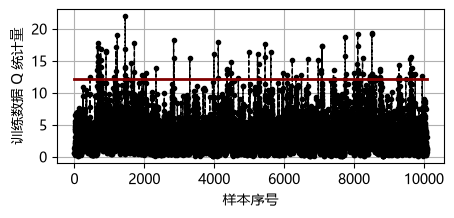

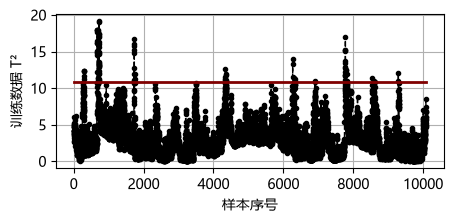

In [12]:
# 带控制限的Q_train图
plt.figure(figsize=(5,2))
plt.plot(Q_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(Q_train)],[Q_CL,Q_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 Q 统计量')
plt.grid()
           
# 带控制限的T2_train图
plt.figure(figsize=(5,2))
plt.plot(T2_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_train)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()
plt.show()

In [13]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#                       故障数据分析
############################################################################### 

In [14]:
# 获取测试数据并归一化
data_test = pd.read_csv('UAf_decrease_outputs.csv', header=None).values
data_test = data_test[:,1:]
data_test_normal = scaler.transform(data_test)

In [15]:
# 计算得分并重构
score_test = pca.transform(data_test_normal)
score_test_reduced = score_test[:,0:k]
data_test_normal_reconstruct = np.dot(score_test_reduced, P_matrix.T)

In [16]:
#计算T2_test
T2_test = np.zeros((data_test_normal.shape[0],))
for i in range(data_test_normal.shape[0]):
    T2_test[i] = np.dot(np.dot(score_test_reduced[i,:], lambda_k_inv), score_test_reduced[i,:].T)

In [17]:
#计算Q_test
error_test = data_test_normal_reconstruct - data_test_normal
Q_test = np.sum(error_test*error_test, axis = 1)

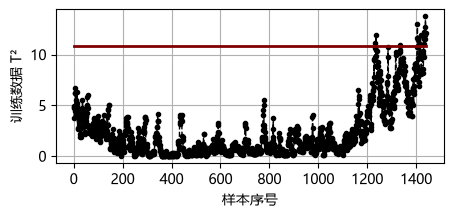

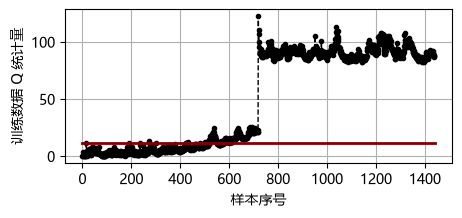

In [18]:
# 绘制T2_test
plt.figure(figsize=(5,2))
plt.plot(T2_test, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_test)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()

# 绘制Q_test
plt.figure(figsize=(5,2))
plt.plot(Q_test, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(Q_test)],[Q_CL,Q_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 Q 统计量')
plt.grid()
plt.show()

In [19]:
##%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                  使用贡献图进行故障诊断
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

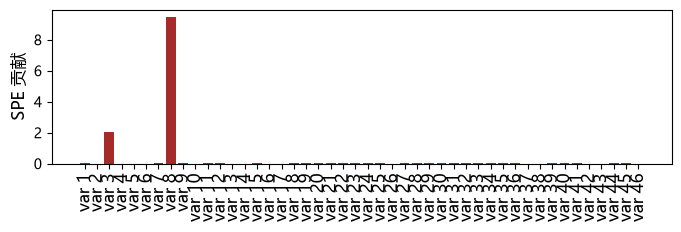

In [20]:
#%% Q contribution
sample = 600

error_test_sample = error_test[sample-1,]
Q_contri = error_test_sample*error_test_sample # vector of contributions

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(Q_contri))], Q_contri, color='brown')
plt.xticks(rotation = 90, fontsize=12)
plt.ylabel('SPE 贡献', fontsize=12)
plt.show()

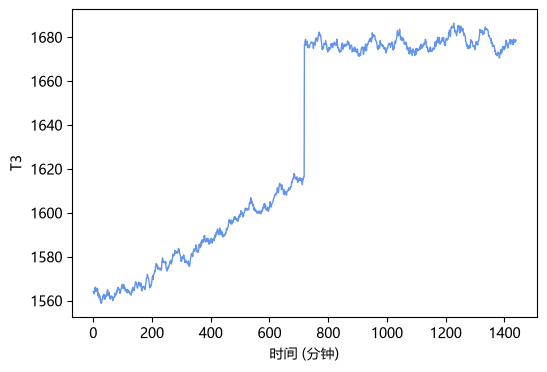

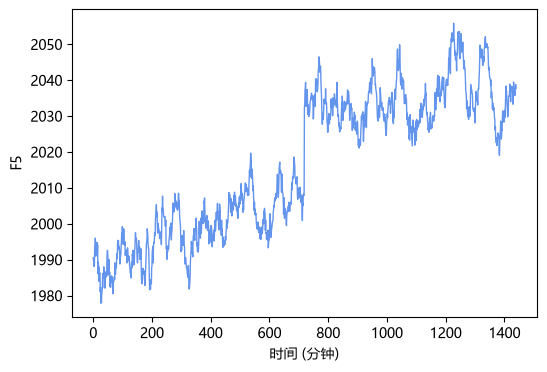

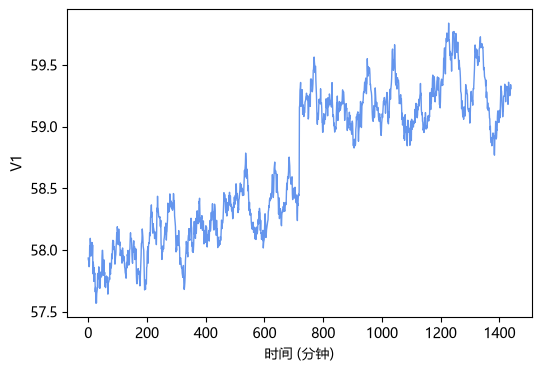

In [21]:
# 绘制诊断排名靠前的变量
plt.figure(figsize=[6,4])
plt.plot(data_test[:,7],'cornflowerblue', linewidth=1)
plt.xlabel('时间 (分钟)')
plt.ylabel('T3')

plt.figure(figsize=[6,4])
plt.plot(data_test[:,27],'cornflowerblue', linewidth=1)
plt.xlabel('时间 (分钟)')
plt.ylabel('F5')

plt.figure(figsize=[6,4])
plt.plot(data_test[:,21],'cornflowerblue', linewidth=1)
plt.xlabel('时间 (分钟)')
plt.ylabel('V1')
plt.show()